 Initializing Machine Learning Training & Evaluation Pipeline...
Loaded dataset with 100000 rows and 20 columns.

 Class Balance Check (Target: Is_High_Risk):
Is_High_Risk
1    66.631
0    33.369
Name: proportion, dtype: float64

Data Split: Train Shape (80000, 5) | Test Shape (20000, 5)

🌲 Training Random Forest Classifier (Optimizing for Class Weights)...

 Model Evaluation Metrics:
              precision    recall  f1-score   support

           0       0.33      0.48      0.39      6674
           1       0.67      0.52      0.59     13326

    accuracy                           0.51     20000
   macro avg       0.50      0.50      0.49     20000
weighted avg       0.56      0.51      0.52     20000



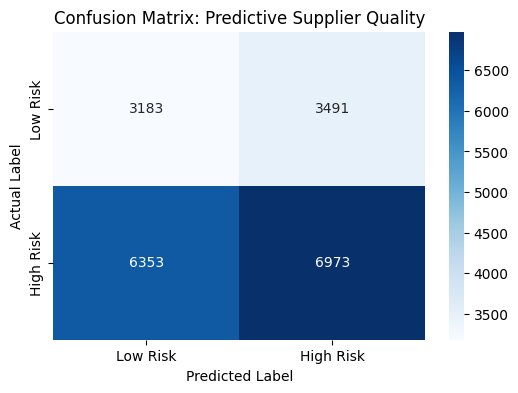

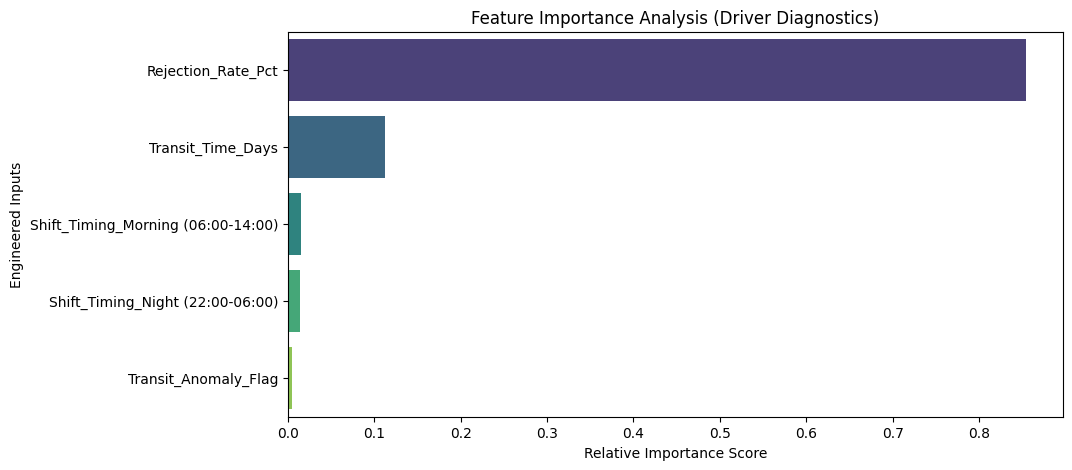


 Model training complete. Evaluating outputs...


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print(" Initializing Machine Learning Training & Evaluation Pipeline...")


# 1. LOAD ENGINEERED DATASET

# Reading the clean dataset created in our previous step
df = pd.read_csv('../data/processed/honda_wms_engineered.csv')
print(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")


# 2. DEFINE TARGET & BUSINESS RULE ALIGNMENT (Point 7)

# Aligning with business rules liek creatnig a binary target where 1 = High/Critical Risk shipment
# Defect severity of Critical or Major flags a shipment as an operational hazard.
df['Is_High_Risk'] = np.where(df['Defect_Severity'].isin(['Critical (Total Scrap)', 'Major (Return to Supplier)']), 1, 0)

print("\n Class Balance Check (Target: Is_High_Risk):")
print(df['Is_High_Risk'].value_counts(normalize=True) * 100)


# 3. FEATURE SELECTION & ENCODING

# Select features that an inspector would realistically know at runtime
feature_cols = ['Shift_Timing', 'Transit_Time_Days', 'Transit_Anomaly_Flag', 'Rejection_Rate_Pct']
X = df[feature_cols]
y = df['Is_High_Risk']

# Convert categorical columns (like Shift_Timing) into numerical dummy variables
X = pd.get_dummies(X, drop_first=True)


# 4. TRAIN-TEST SPLIT (Point 5)

# 80% training for pattern recognition, 20% testing for strict verification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nData Split: Train Shape {X_train.shape} | Test Shape {X_test.shape}")


# 5. MODEL SELECTION & TRAINING (Point 5)

print("\n🌲 Training Random Forest Classifier (Optimizing for Class Weights)...")
# Using class_weight='balanced' to handle any underlying class imbalance directly
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)


# 6. MODEL EVALUATION & METRICS (Point 6)

y_pred = model.predict(X_test)

print("\n Model Evaluation Metrics:")
print(classification_report(y_test, y_pred))

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Risk', 'High Risk'], yticklabels=['Low Risk', 'High Risk'])
plt.title('Confusion Matrix: Predictive Supplier Quality')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


# 7. FEATURE IMPORTANCE DOCUMENTATION (Point 2 & 6)

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")
plt.title('Feature Importance Analysis (Driver Diagnostics)')
plt.xlabel('Relative Importance Score')
plt.ylabel('Engineered Inputs')
plt.show()

print("\n Model training complete. Evaluating outputs...")